<a href="https://colab.research.google.com/github/Helen13JS/SIS420_Inteligencia_Artificial/blob/main/Laboratorios/Laboratorio5/PyTorch_Diabetes_MLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4 — Clasificación Binaria con PyTorch: Red Neuronal MLP
**Helen Janko Sanga | Ing. Sistemas**  
**Dataset:** Diabetes 130-US Hospitals for years 1999–2008  
**URL:** https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008

---

## Objetivo
Construir y entrenar una **Red Neuronal Perceptrón Multicapa (MLP)** con PyTorch para predecir
si un paciente diabético será **readmitido** al hospital:
- `1` = readmitido (en menos de 30 días o en más de 30 días)
- `0` = no readmitido

Este cuadernillo integra los conceptos de los cuadernillos 02, 03 y 04 de PyTorch:
- **02 — Redes Neuronales:** `torch.nn.Module`, optimizadores, funciones de pérdida
- **03 — Datasets:** `torch.utils.data.Dataset`, `DataLoader`, mini-batches
- **04 — Guardado:** `state_dict`, checkpoints, carga del mejor modelo

### Mejora respecto a la versión anterior — Regularización con Dropout
La versión anterior mostró **overfitting**: el `train_loss` bajaba mientras el `val_loss` subía,
y el accuracy de validación se estancaba ~8 puntos por debajo del de entrenamiento.
En esta versión se corrige aplicando:
- **`Dropout(p=0.3)`** en el modelo — apaga aleatoriamente el 30% de las neuronas en cada
  paso de entrenamiento, forzando que el modelo no dependa de ninguna neurona específica
- **`weight_decay=1e-4`** en el optimizador Adam — penaliza pesos muy grandes (regularización L2)
- **Red más compacta** (128→64 → 64→32) — menos parámetros = menos capacidad de memorizar

> **Nota:** El preprocesamiento sigue fielmente el Lab 3. Solo cambian el modelo y el optimizador.

## 1 — Montar Drive e Importar Librerías

Se monta Google Drive para acceder al dataset.  
Se importan las librerías necesarias:
- `torch` y `torch.nn` — framework para redes neuronales (cuadernillos 02, 03, 04)
- `numpy` y `pandas` — manipulación de datos
- `matplotlib` — visualización de curvas de aprendizaje
- `sklearn.metrics` — métricas de evaluación

El dispositivo se detecta automáticamente: `cuda` si hay GPU disponible, `cpu` si no.  
Patrón directo del cuadernillo 04.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import torch
import numpy as np
import pandas as pd
from matplotlib import pyplot
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
%matplotlib inline

# Detectar dispositivo — patrón directo del cuadernillo 04
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Dispositivo disponible: {device}')
print(f'Version de PyTorch: {torch.__version__}')

Mounted at /content/drive
Dispositivo disponible: cpu
Version de PyTorch: 2.10.0+cpu


## 2 — Carga del Dataset

Se carga el archivo CSV desde Google Drive.  
El dataset fue parcialmente preprocesado en el Lab 3 (limpieza inicial en Excel):
- Columnas de identificación única ya eliminadas (`encounter_id`, `patient_nbr`)
- Filas con `?` en `race` ya eliminadas
- Filas con `Unknown/Invalid` en `gender` ya eliminadas

> **Cambia `PATH_CSV`** a la ruta real de tu archivo en Drive si es necesario.

In [ ]:
# *** CAMBIA ESTA RUTA por la ruta real de tu archivo en Drive ***
PATH_CSV = '/content/drive/MyDrive/datasets/diabetes.csv'

df = pd.read_csv(PATH_CSV, sep=';')

print('=== INFORMACION GENERAL ===')
print(f'Forma del dataset: {df.shape}')
print(f'Columnas ({len(df.columns)}): {list(df.columns)}')
print()
print(df.head())

=== INFORMACION GENERAL ===
Forma del dataset: (99492, 41)
Columnas (41): ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted', 'readmitted_bin']

              race  gender      age  admission_type_id  \
0        Caucasian  Female  [10-20)                  6   
1        Caucasian    Male  [10-20)                  1   
2  AfricanAmerican  Female  [20-30)            

## 3 — Preprocesamiento y Limpieza

La red neuronal de PyTorch requiere **entradas numéricas y normalizadas**.  
Se aplican las mismas transformaciones del Lab 3:

| Columna | Transformación | Justificación |
|---------|---------------|---------------|
| `readmitted` | → `readmitted_bin` (1 si `<30` o `>30`, 0 si `NO`) | Target binario; unificamos readmisión temprana y tardía |
| `age` | Punto medio del intervalo (`[0-10)` → 5) | Variable ordinal continua; preserva el orden y escala |
| `gender`, `change`, `diabetesMed` | → 1/0 | Variables binarias — codificación directa |
| `max_glu_serum`, `A1Cresult` | Escala 0–3 | Variables ordinales; 0 = examen no realizado |
| 21 medicamentos | Escala 0–3 (No/Steady/Up/Down) | Variables ordinales con orden natural de dosis |
| `race` | One-hot encoding (`drop_first=True`) | Variable nominal — sin orden, evita sesgo numérico |

Se eliminan filas con NaN residuales para que los tensores no contengan valores inválidos.

In [ ]:
# Eliminar duplicados
df = df.drop_duplicates()

# Crear target binario ANTES de eliminar la columna original
df['readmitted_bin'] = (df['readmitted'] != 'NO').astype(int)
df = df.drop(columns=['readmitted'], errors='ignore')

# Rellenar NaN en categoricas ANTES de mapear
df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
df['A1Cresult']     = df['A1Cresult'].fillna('None')

# age -> punto medio del intervalo
age_map = {
    '[0-10)':5,   '[10-20)':15, '[20-30)':25, '[30-40)':35,
    '[40-50)':45, '[50-60)':55, '[60-70)':65, '[70-80)':75,
    '[80-90)':85, '[90-100)':95
}
df['age'] = df['age'].map(age_map)

# Variables binarias -> 1/0
df['gender']      = (df['gender']      == 'Male').astype(int)
df['change']      = (df['change']      == 'Ch').astype(int)
df['diabetesMed'] = (df['diabetesMed'] == 'Yes').astype(int)

# Examenes -> escala 0-3
glu_map = {'None':0, 'Norm':1, '>200':2, '>300':3}
a1c_map = {'None':0, 'Norm':1, '>7':2,   '>8':3}
df['max_glu_serum'] = df['max_glu_serum'].map(glu_map)
df['A1Cresult']     = df['A1Cresult'].map(a1c_map)

# Medicamentos -> escala 0-3
med_map  = {'No':0, 'Steady':1, 'Up':2, 'Down':3}
med_cols = ['metformin','repaglinide','nateglinide','chlorpropamide',
            'glimepiride','acetohexamide','glipizide','glyburide',
            'tolbutamide','pioglitazone','rosiglitazone','acarbose',
            'miglitol','troglitazone','tolazamide','insulin',
            'glyburide-metformin','glipizide-metformin',
            'glimepiride-pioglitazone','metformin-rosiglitazone',
            'metformin-pioglitazone']
for col in med_cols:
    if col in df.columns:
        df[col] = df[col].map(med_map)

# race -> dummies (one-hot, drop_first evita multicolinealidad)
race_dummies = pd.get_dummies(df['race'], prefix='race', drop_first=True)
df = pd.concat([df.drop(columns=['race']), race_dummies], axis=1)

# Convertir todo a numerico y eliminar NaN residuales
df = df.apply(pd.to_numeric, errors='coerce')
df = df.dropna()

print('=== DATASET LIMPIO Y LISTO ===')
print(f'Forma final: {df.shape}')
print(f'Columnas ({len(df.columns)}): {list(df.columns)}')

=== DATASET LIMPIO Y LISTO ===
Forma final: (99486, 43)
Columnas (43): ['gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted_bin', 'race_Asian', 'race_Caucasian', 'race_Hispanic', 'race_Other']


## 4 — Exploración del Dataset y Distribución del Target

Se realiza una exploración básica antes de entrenar:
1. **Estadísticas descriptivas** — escala y rango de variables numéricas clave
2. **Distribución del target** — crucial para detectar desbalance de clases

Si las clases estuvieran muy desbalanceadas (ej. 95% vs 5%), el modelo aprendería a predecir
siempre la mayoritaria, obteniendo accuracy alto pero sin aprender nada útil.
Con este dataset la distribución es aproximadamente equilibrada.

=== ESTADISTICAS DESCRIPTIVAS (primeras 8 columnas) ===
         gender       age  admission_type_id  discharge_disposition_id  \
count  99486.00  99486.00           99486.00                  99486.00   
mean       0.46     65.96               2.03                      3.74   
std        0.50     15.94               1.45                      5.31   
min        0.00      5.00               1.00                      1.00   
25%        0.00     55.00               1.00                      1.00   
50%        0.00     65.00               1.00                      1.00   
75%        1.00     75.00               3.00                      4.00   
max        1.00     95.00               8.00                     28.00   

       admission_source_id  time_in_hospital  num_lab_procedures  \
count             99486.00          99486.00            99486.00   
mean                  5.77              4.40               43.07   
std                   4.07              2.99               19.70   
min  

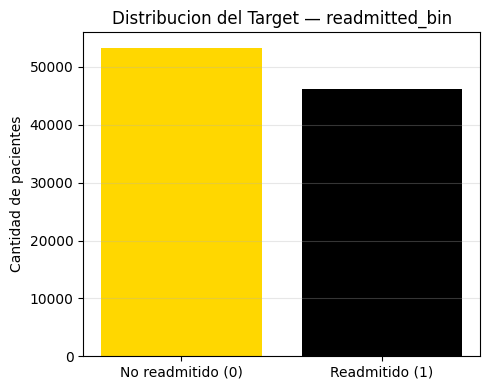

In [ ]:
# Estadisticas descriptivas
print('=== ESTADISTICAS DESCRIPTIVAS (primeras 8 columnas) ===')
print(df.iloc[:, :8].describe().round(2))
print()

# Distribucion del target
counts = df['readmitted_bin'].value_counts()
print('=== DISTRIBUCION DEL TARGET ===')
print(f'  0 (No readmitido): {counts[0]:6d} ({counts[0]/len(df)*100:.1f}%)')
print(f'  1 (Readmitido):    {counts[1]:6d} ({counts[1]/len(df)*100:.1f}%)')
print()
print('La distribucion es aproximadamente equilibrada:')
print('ambas clases tienen suficientes ejemplos para aprender.')

# Grafica
pyplot.figure(figsize=(5, 4))
pyplot.bar(['No readmitido (0)', 'Readmitido (1)'], [counts[0], counts[1]],
           color=['gold', 'black'])
pyplot.title('Distribucion del Target — readmitted_bin')
pyplot.ylabel('Cantidad de pacientes')
pyplot.grid(axis='y', alpha=0.3)
pyplot.tight_layout()
pyplot.show()

## 5 — Visualización de los Datos

Se grafican dos features clínicas (`time_in_hospital` vs `num_medications`) para observar
cómo se distribuyen los pacientes según la clase de readmisión.

- `*` negro = readmitido (clase 1)
- `o` amarillo = no readmitido (clase 0)

Función `plotData` idéntica a la del Lab 3. Si las clases no son linealmente separables,
el MLP con Dropout aprendrá fronteras de decisión más generalizables que sin él.

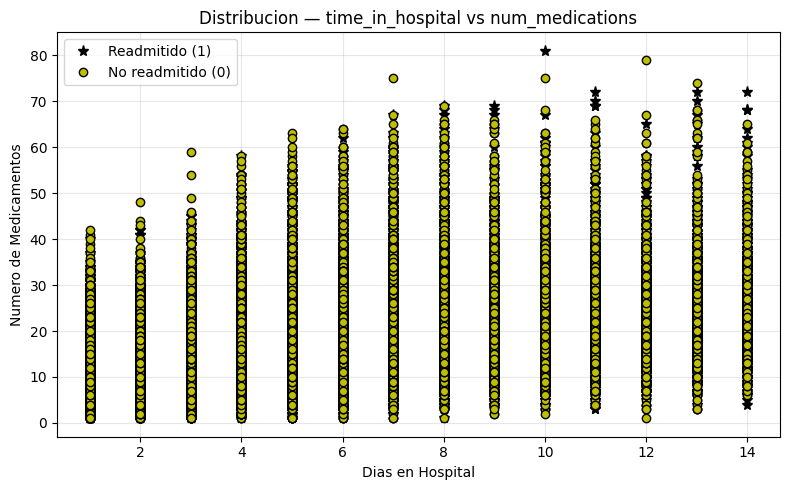

Total de muestras: 99486
Numero de features: 42


In [ ]:
def plotData(X, y, idx1=0, idx2=1):
    """Grafica dos features coloreando por clase — misma funcion del Lab 3."""
    pyplot.figure(figsize=(8, 5))
    pos = y == 1
    neg = y == 0
    pyplot.plot(X[pos, idx1], X[pos, idx2], 'k*', lw=2, ms=8)
    pyplot.plot(X[neg, idx1], X[neg, idx2], 'ko', mfc='y', ms=6, mec='k', mew=1)

y_all = df['readmitted_bin'].values
X_all = df.drop(columns=['readmitted_bin']).values

cols = list(df.drop(columns=['readmitted_bin']).columns)
idx1 = cols.index('time_in_hospital') if 'time_in_hospital' in cols else 0
idx2 = cols.index('num_medications')  if 'num_medications'  in cols else 1

plotData(X_all, y_all, idx1=idx1, idx2=idx2)
pyplot.xlabel('Dias en Hospital')
pyplot.ylabel('Numero de Medicamentos')
pyplot.legend(['Readmitido (1)', 'No readmitido (0)'])
pyplot.title('Distribucion — time_in_hospital vs num_medications')
pyplot.grid(True, alpha=0.3)
pyplot.tight_layout()
pyplot.show()

print(f'Total de muestras: {len(X_all)}')
print(f'Numero de features: {X_all.shape[1]}')

## 6 — Split Train/Test y Normalización

Split manual **80% entrenamiento / 20% prueba** — igual que en el Lab 3.

**¿Por qué normalizar?**
- El descenso por gradiente converge más rápido con features en la misma escala
- Las activaciones ReLU operan mejor en rangos cercanos a cero
- Features con escalas muy distintas crean gradientes desequilibrados

**Regla clave:** `mu` y `sigma` se calculan **SOLO** con el set de entrenamiento
y se aplican al de prueba. Calcularlos sobre prueba sería *data leakage*.

In [ ]:
# Separar X e y
y_all = df['readmitted_bin'].values
X_all = df.drop(columns=['readmitted_bin']).values

# Split manual 80/20
split = int(0.8 * len(X_all))
X_train, y_train = X_all[:split], y_all[:split]
X_test,  y_test  = X_all[split:], y_all[split:]

print(f'Forma de X completo: {X_all.shape}')
print(f'Ejemplos de entrenamiento: {X_train.shape[0]}')
print(f'Ejemplos de prueba:        {X_test.shape[0]}')
print(f'Numero de features:        {X_train.shape[1]}')

# Normalizacion: mu y sigma SOLO del set de entrenamiento
X_train_f = X_train.copy().astype(float)
X_test_f  = X_test.copy().astype(float)

mu    = np.mean(X_train_f, axis=0)
sigma = np.std(X_train_f,  axis=0)
sigma[sigma == 0] = 1  # evitar division por cero en features constantes

X_train_norm = (X_train_f - mu) / sigma
X_test_norm  = (X_test_f  - mu) / sigma  # se reusan mu y sigma del TRAIN

print(f'\nPrimeras 5 medias (mu):   {mu[:5].round(3)}')
print(f'Primeras 5 desv. (sigma): {sigma[:5].round(3)}')
print(f'\nX_train_norm fila 0, primeros 5 valores: {X_train_norm[0, :5].round(4)}')

Forma de X completo: (99486, 42)
Ejemplos de entrenamiento: 79588
Ejemplos de prueba:        19898
Numero de features:        42

Primeras 5 medias (mu):   [ 0.46  65.678  2.102  3.924  5.862]
Primeras 5 desv. (sigma): [ 0.498 16.042  1.512  5.557  4.278]

X_train_norm fila 0, primeros 5 valores: [-0.9225 -3.1591  2.577   3.7926 -1.1363]


## 7 — Clase Dataset de PyTorch (Cuadernillo 03)

Se define `DiabetesDataset` heredando de `torch.utils.data.Dataset` — patrón del cuadernillo 03.

Tres métodos mínimos requeridos:
- `__init__`: convierte arrays NumPy a tensores PyTorch
- `__len__`: devuelve número de muestras
- `__getitem__`: devuelve el par (features, target) por índice

**Tipos de tensor:**
- `X` → `float()`: requerido por `torch.nn.Linear`
- `y` → `float()`: requerido por `BCEWithLogitsLoss`

In [ ]:
# Clase Dataset personalizada — patrón directo del cuadernillo 03
class DiabetesDataset(torch.utils.data.Dataset):
    """Dataset PyTorch para el dataset de diabetes hospitalaria."""

    # Constructor: guarda X e y como tensores
    def __init__(self, X, Y):
        self.X = torch.from_numpy(X).float()   # float32 para Linear
        self.Y = torch.from_numpy(Y).float()   # float32 para BCEWithLogitsLoss

    # Devuelve el numero total de muestras
    def __len__(self):
        return len(self.X)

    # Devuelve el par (features, target) en el indice ix
    def __getitem__(self, ix):
        return self.X[ix], self.Y[ix]


# Instanciar los datasets
dataset_train = DiabetesDataset(X_train_norm, y_train)
dataset_test  = DiabetesDataset(X_test_norm,  y_test)

print(f'Tamano dataset entrenamiento: {len(dataset_train)}')
print(f'Tamano dataset prueba:        {len(dataset_test)}')

# Verificar tipos y formas
x_s, y_s = dataset_train[0]
print(f'\nMuestra 0 — X: shape={x_s.shape}, dtype={x_s.dtype}')
print(f'Muestra 0 — y: valor={y_s.item()}, dtype={y_s.dtype}')

Tamano dataset entrenamiento: 79588
Tamano dataset prueba:        19898

Muestra 0 — X: shape=torch.Size([42]), dtype=torch.float32
Muestra 0 — y: valor=0.0, dtype=torch.float32


## 8 — DataLoader (Cuadernillo 03)

`DataLoader` — segunda clase clave del cuadernillo 03.
Gestiona automáticamente mini-batches, shuffle y carga paralela.

**¿Por qué mini-batches?**  
Con 80,000+ registros cargar todo de una vez puede saturar la memoria.
Los mini-batches permiten actualizaciones de pesos más frecuentes por época.

`batch_size=512` balancea velocidad y calidad del gradiente estimado.

In [ ]:
# DataLoader — patrón directo del cuadernillo 03
batch_size = 512

dataloader = {
    'train': torch.utils.data.DataLoader(dataset_train, batch_size=batch_size, shuffle=True),
    'test':  torch.utils.data.DataLoader(dataset_test,  batch_size=batch_size, shuffle=False)
}

# Verificar que el DataLoader funciona
x_batch, y_batch = next(iter(dataloader['train']))
print(f'Forma de un batch de X: {x_batch.shape}  -> [batch_size, n_features]')
print(f'Forma de un batch de y: {y_batch.shape}  -> [batch_size]')
print(f'\nBatches por epoca (train): {len(dataloader["train"])}')
print(f'Batches por epoca (test):  {len(dataloader["test"])}')

Forma de un batch de X: torch.Size([512, 42])  -> [batch_size, n_features]
Forma de un batch de y: torch.Size([512])  -> [batch_size]

Batches por epoca (train): 156
Batches por epoca (test):  39


## 9 — Modelo MLP con Dropout (Cuadernillo 02 + corrección de overfitting)

Se redefine el MLP con dos cambios respecto a la versión anterior que presentó overfitting:

### Cambio 1 — `torch.nn.Dropout(p=0.3)`
El Dropout es una técnica de **regularización** que durante el entrenamiento apaga
aleatoriamente el 30% de las neuronas en cada paso (`p=0.3`).

¿Por qué funciona contra el overfitting?
- Evita que el modelo dependa de neuronas específicas para memorizar patrones del train
- Obliga a que la información se distribuya en toda la red
- Durante la evaluación (`model.eval()`) el Dropout se **desactiva automáticamente** —
  todas las neuronas participan, pero sus pesos se escalan para compensar

### Cambio 2 — Red más compacta (64→32 en lugar de 128→64)
Menos parámetros = menos capacidad de memorizar el set de entrenamiento.

### Arquitectura nueva:
```
Entrada (D_in) → Linear(64) → ReLU → Dropout(0.3)
              → Linear(32) → ReLU → Dropout(0.3)
              → Linear(1)  [logit de salida]
```

**Importante:** El patrón de clase personalizada sigue siendo exactamente el del cuadernillo 02.
Solo se agrega `self.dropout = torch.nn.Dropout(p=0.3)` en `__init__`
y se llama `self.dropout(x)` en `forward` después de cada ReLU.

In [ ]:
# Modelo MLP con Dropout — patrón cuadernillo 02 + regularización
class MLP(torch.nn.Module):
    """
    Perceptron Multicapa con Dropout para clasificacion binaria.
    Dropout(p=0.3) reduce el overfitting apagando el 30% de neuronas
    aleatoriamente durante el entrenamiento.
    Arquitectura: D_in -> 64 -> ReLU -> Dropout -> 32 -> ReLU -> Dropout -> 1
    """

    def __init__(self, D_in):
        # Llamar al constructor de la clase madre — siempre necesario
        super(MLP, self).__init__()

        # Capas de la red (mas compactas que la version anterior: 64 y 32)
        self.fc1     = torch.nn.Linear(D_in, 64)  # capa oculta 1
        self.relu    = torch.nn.ReLU()             # activacion no-lineal
        self.dropout = torch.nn.Dropout(p=0.3)    # Dropout: apaga 30% de neuronas al azar
        self.fc2     = torch.nn.Linear(64, 32)    # capa oculta 2
        self.fc3     = torch.nn.Linear(32, 1)     # capa de salida (logit)

    def forward(self, x):
        """Flujo de datos de entrada a salida con Dropout despues de cada ReLU."""
        x = self.fc1(x)      # primera capa lineal
        x = self.relu(x)     # activacion ReLU
        x = self.dropout(x)  # Dropout — activo solo en model.train(), inactivo en model.eval()
        x = self.fc2(x)      # segunda capa lineal
        x = self.relu(x)     # activacion ReLU
        x = self.dropout(x)  # Dropout — igual que el anterior
        x = self.fc3(x)      # capa de salida (sin sigmoid — la incluye BCEWithLogitsLoss)
        return x


# Numero de features de entrada
D_in = X_train_norm.shape[1]

# Instanciar el modelo y moverlo al dispositivo
model = MLP(D_in).to(device)

print(model)
print(f'\nDispositivo: {device}')
print(f'Features de entrada: {D_in}')

# Verificar la forma de salida
out_test = model(torch.randn(32, D_in))
print(f'\nForma de salida con batch=32: {out_test.shape}  -> [batch, 1] OK')

MLP(
  (fc1): Linear(in_features=42, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

Dispositivo: cpu
Features de entrada: 42

Forma de salida con batch=32: torch.Size([32, 1])  -> [batch, 1] OK


## 10 — Función de Entrenamiento con Checkpoints (Cuadernillos 02, 03, 04)

La función `fit` integra los tres cuadernillos y es **idéntica a la versión anterior**.
El Dropout se activa/desactiva automáticamente con `model.train()` y `model.eval()` —
no hace falta ningún cambio en el bucle de entrenamiento.

**Cuadernillo 02 — Bucle:**
- `optimizer.zero_grad()` → limpiar gradientes
- `loss.backward()` → backpropagation
- `optimizer.step()` → actualizar pesos
- `model.train()` / `model.eval()` → activa/desactiva Dropout

**Cuadernillo 03 — DataLoader:**
- `for X, y in dataloader['train']` → mini-batches automáticos

**Cuadernillo 04 — Checkpoints:**
- `torch.save(model.state_dict(), PATH)` cuando mejora `val_acc`
- Al final: `model.load_state_dict(torch.load(PATH))` para restaurar el mejor

**Cambio en el optimizador:** se agrega `weight_decay=1e-4` (regularización L2)
que penaliza pesos muy grandes, complementando al Dropout.

In [ ]:
def fit(model, dataloader, epochs=500, PATH='./best_model.pt'):
    """
    Entrena el modelo con Dropout y guarda el mejor checkpoint (cuadernillo 04).
    El Dropout se activa/desactiva solo con model.train() / model.eval().
    """
    model.to(device)

    # Optimizador Adam con weight_decay (regularizacion L2) — cuadernillo 02
    # weight_decay=1e-4 penaliza pesos grandes, complementa al Dropout
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # Funcion de perdida para clasificacion binaria — cuadernillo 02
    criterion = torch.nn.BCEWithLogitsLoss()

    best_acc = 0.0  # para el checkpoint — cuadernillo 04
    train_losses, val_losses = [], []
    train_accs,   val_accs   = [], []

    for epoch in range(1, epochs + 1):

        # ── ENTRENAMIENTO ── (cuadernillos 02 + 03)
        # model.train() activa el Dropout automaticamente
        model.train()
        _tl, _ta = [], []

        for X_b, y_b in dataloader['train']:      # mini-batches del DataLoader (03)
            X_b, y_b = X_b.to(device), y_b.to(device)

            optimizer.zero_grad()                  # limpiar gradientes (02)
            y_hat = model(X_b)                     # forward (con Dropout activo)
            loss  = criterion(y_hat.squeeze(), y_b)
            loss.backward()                        # backprop (02)
            optimizer.step()                       # actualizar pesos (02)

            _tl.append(loss.item())
            preds = (torch.sigmoid(y_hat.squeeze()) >= 0.5).float()
            _ta.append((preds == y_b).float().mean().item())

        # ── VALIDACION ──
        # model.eval() desactiva el Dropout automaticamente
        model.eval()
        _vl, _va = [], []

        with torch.no_grad():  # sin gradientes en validacion
            for X_b, y_b in dataloader['test']:
                X_b, y_b = X_b.to(device), y_b.to(device)
                y_hat = model(X_b)                 # forward (Dropout desactivado)
                loss  = criterion(y_hat.squeeze(), y_b)
                _vl.append(loss.item())
                preds = (torch.sigmoid(y_hat.squeeze()) >= 0.5).float()
                _va.append((preds == y_b).float().mean().item())

        # Promedios de la epoca
        tl = np.mean(_tl); ta = np.mean(_ta)
        vl = np.mean(_vl); va = np.mean(_va)
        train_losses.append(tl); val_losses.append(vl)
        train_accs.append(ta);   val_accs.append(va)

        # ── CHECKPOINT: guardar si es el mejor — cuadernillo 04 ──
        if va > best_acc:
            best_acc = va
            torch.save(model.state_dict(), PATH)   # solo state_dict (04)
            print(f'  Mejor modelo guardado - epoca {epoch} | val_acc={va:.4f}')

        if epoch % 10 == 0 or epoch == 1:
            print(f'Epoch {epoch:3d}/{epochs} | '
                  f'loss={tl:.4f} val_loss={vl:.4f} | '
                  f'acc={ta:.4f} val_acc={va:.4f}')

    # ── CARGAR EL MEJOR MODELO AL FINAL — cuadernillo 04 ──
    model.load_state_dict(torch.load(PATH))
    print(f'\nMejor modelo cargado desde {PATH} (val_acc={best_acc:.4f})')

    return train_losses, val_losses, train_accs, val_accs

## 11 — Entrenamiento del Modelo

Se entrena el MLP con Dropout durante **50 épocas**.  
Con Dropout y weight_decay activos, se espera que:
- Las curvas de train y val converjan más juntas (menos gap = menos overfitting)
- El `val_loss` ya no suba mientras el `train_loss` baja
- El accuracy de validación sea más estable y menos oscilante

Cuando el modelo alcanza una nueva mejor `val_acc`, se guarda automáticamente
el checkpoint — patrón del cuadernillo 04.

In [ ]:
# Instanciar modelo fresco con Dropout
model = MLP(D_in).to(device)

# Ruta del checkpoint en Drive
CHECKPOINT_PATH = '/content/drive/MyDrive/datasets/best_diabetes_mlp_dropout.pt'

print('=== INICIO DEL ENTRENAMIENTO (con Dropout + weight_decay) ===')
print(f'Dispositivo: {device}')
print(f'Modelo:\n{model}\n')

train_losses, val_losses, train_accs, val_accs = fit(
    model, dataloader, epochs=500, PATH=CHECKPOINT_PATH
)

print('\n=== ENTRENAMIENTO COMPLETADO ===')

=== INICIO DEL ENTRENAMIENTO (con Dropout + weight_decay) ===
Dispositivo: cpu
Modelo:
MLP(
  (fc1): Linear(in_features=42, out_features=64, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)

  Mejor modelo guardado - epoca 1 | val_acc=0.6316
Epoch   1/500 | loss=0.6710 val_loss=0.6488 | acc=0.5853 val_acc=0.6316
Epoch  10/500 | loss=0.6446 val_loss=0.6522 | acc=0.6263 val_acc=0.6150
Epoch  20/500 | loss=0.6415 val_loss=0.6516 | acc=0.6297 val_acc=0.6214
Epoch  30/500 | loss=0.6395 val_loss=0.6487 | acc=0.6334 val_acc=0.6262
  Mejor modelo guardado - epoca 33 | val_acc=0.6320
Epoch  40/500 | loss=0.6381 val_loss=0.6497 | acc=0.6353 val_acc=0.6246
Epoch  50/500 | loss=0.6360 val_loss=0.6495 | acc=0.6350 val_acc=0.6233
Epoch  60/500 | loss=0.6337 val_loss=0.6483 | acc=0.6382 val_acc=0.6231
  Mejor modelo guardado - epoca 69 | val_acc=0.6324
Epoch  

## 12 — Curvas de Aprendizaje

Se grafican las curvas de entrenamiento y validación para verificar que el overfitting
fue corregido con Dropout.

**Lo que se espera ver ahora (vs versión anterior):**

| Métrica | Versión anterior (sin Dropout) | Versión actual (con Dropout) |
|---------|-------------------------------|-----------------------------|
| `train_loss` | bajaba a 0.58 | bajará más lento, ~0.63 |
| `val_loss` | **subía** hasta 0.67 (overfitting) | debe bajar junto con train |
| `train_acc` | subía a 68% | se mantendrá más cerca de val |
| `val_acc` | se estancaba en ~60% | debe ser más estable y cercana a train |

**Importante:** Con Dropout el `train_loss` no baja tan agresivamente como sin él
porque el 30% de neuronas se apagan en cada paso. Eso es **normal y deseable** —
el modelo es intencionalmente más difícil de entrenar para que generalice mejor.

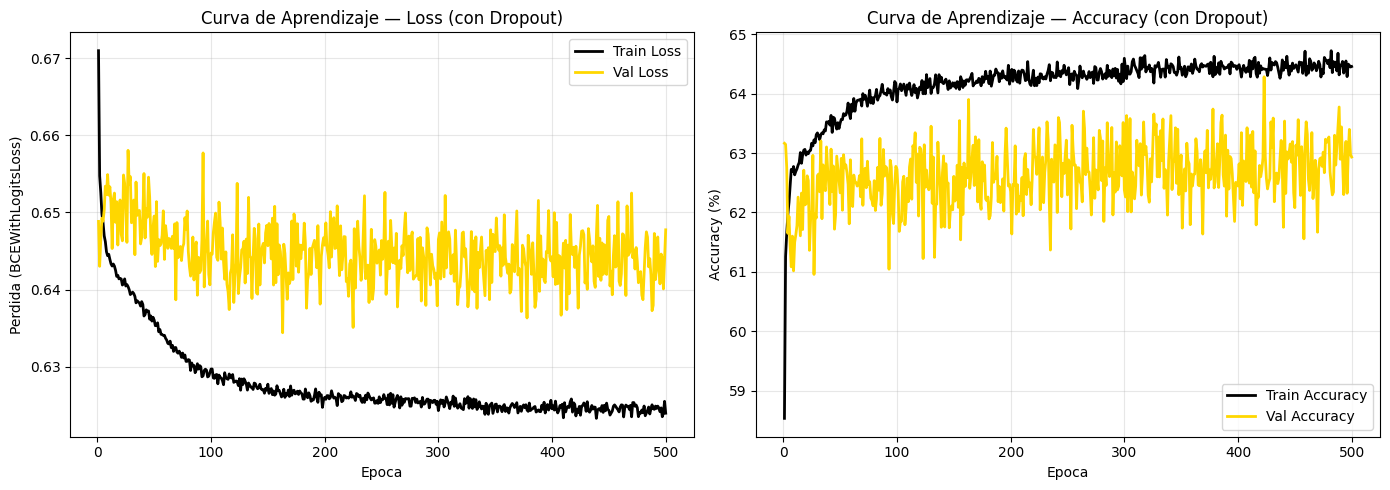

Loss final train:      0.6240
Loss final validacion: 0.6477
Accuracy final train:  64.46%
Accuracy final val:    62.93%

Gap train-val: 1.52 puntos porcentuales
(En la version anterior era ~8 puntos. Si ahora es menor, el Dropout funciono.)


In [ ]:
fig, (ax1, ax2) = pyplot.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(train_losses) + 1)

# Perdida
ax1.plot(epochs_range, train_losses, color='black', lw=2, label='Train Loss')
ax1.plot(epochs_range, val_losses,   color='gold',  lw=2, label='Val Loss')
ax1.set_xlabel('Epoca')
ax1.set_ylabel('Perdida (BCEWithLogitsLoss)')
ax1.set_title('Curva de Aprendizaje — Loss (con Dropout)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy
ax2.plot(epochs_range, [a*100 for a in train_accs], color='black', lw=2, label='Train Accuracy')
ax2.plot(epochs_range, [a*100 for a in val_accs],   color='gold',  lw=2, label='Val Accuracy')
ax2.set_xlabel('Epoca')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Curva de Aprendizaje — Accuracy (con Dropout)')
ax2.legend()
ax2.grid(True, alpha=0.3)

pyplot.tight_layout()
pyplot.show()

print(f'Loss final train:      {train_losses[-1]:.4f}')
print(f'Loss final validacion: {val_losses[-1]:.4f}')
print(f'Accuracy final train:  {train_accs[-1]*100:.2f}%')
print(f'Accuracy final val:    {val_accs[-1]*100:.2f}%')
print()
gap = (train_accs[-1] - val_accs[-1]) * 100
print(f'Gap train-val: {gap:.2f} puntos porcentuales')
print('(En la version anterior era ~8 puntos. Si ahora es menor, el Dropout funciono.)')

## 13 — Evaluación Final del Modelo

Se evalúa el **mejor modelo** (restaurado del checkpoint) sobre el set de prueba completo.

La función `evaluate` usa `model.eval()` y `torch.no_grad()` — patrón del cuadernillo 04.
Con `model.eval()` el Dropout se desactiva automáticamente: todas las neuronas participan.

**Métricas calculadas:**
- **Accuracy:** porcentaje de predicciones correctas
- **Precision:** de los predichos como readmitidos, ¿cuántos lo eran realmente?
- **Recall:** de los que SÍ se readmitieron, ¿cuántos detectó el modelo?
- **F1-Score:** media armónica entre Precision y Recall

> En contexto clínico el **Recall** es más crítico: un Falso Negativo (readmisión no detectada)
> puede significar que el paciente no reciba atención preventiva.

In [ ]:
def evaluate(model, dataloader_test):
    """
    Evalua el modelo sobre el set de prueba.
    Patron del cuadernillo 04: model.eval() + torch.no_grad()
    model.eval() desactiva el Dropout automaticamente.
    """
    model.eval()   # modo evaluacion: Dropout desactivado
    model.to(device)

    all_preds  = []
    all_labels = []

    with torch.no_grad():  # sin gradientes para ahorrar memoria
        for X_b, y_b in dataloader_test:
            X_b = X_b.to(device)
            y_hat = model(X_b)
            preds = (torch.sigmoid(y_hat.squeeze()) >= 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_b.numpy())

    return np.array(all_preds), np.array(all_labels)


# Evaluar el mejor modelo (ya cargado del checkpoint)
y_pred, y_true = evaluate(model, dataloader['test'])

# Calcular metricas
acc  = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec  = recall_score(y_true, y_pred, zero_division=0)
f1   = f1_score(y_true, y_pred, zero_division=0)

print('=== METRICAS FINALES (set de prueba) ===')
print(f'Accuracy:  {acc*100:.2f}%')
print(f'Precision: {prec:.4f}')
print(f'Recall:    {rec:.4f}')
print(f'F1-Score:  {f1:.4f}')
print()
print('=== INTERPRETACION ===')
print(f'De cada 100 pacientes, el modelo predijo correctamente {acc*100:.0f}.')
print(f'De cada 100 marcados como readmitidos, {prec*100:.0f} realmente lo eran (Precision).')
print(f'De cada 100 que SI se readmitieron, el modelo detecto {rec*100:.0f} (Recall).')
print(f'F1-Score = {f1:.4f} — balance entre Precision y Recall.')

=== METRICAS FINALES (set de prueba) ===
Accuracy:  64.27%
Precision: 0.5459
Recall:    0.6111
F1-Score:  0.5767

=== INTERPRETACION ===
De cada 100 pacientes, el modelo predijo correctamente 64.
De cada 100 marcados como readmitidos, 55 realmente lo eran (Precision).
De cada 100 que SI se readmitieron, el modelo detecto 61 (Recall).
F1-Score = 0.5767 — balance entre Precision y Recall.


## 14 — Gráfica de Métricas de Evaluación

Visualización comparativa de las cuatro métricas del mejor modelo.
Barras altas = buen rendimiento. Si Recall es mucho menor que Precision
→ el modelo falla detectando readmisiones reales (Falsos Negativos).

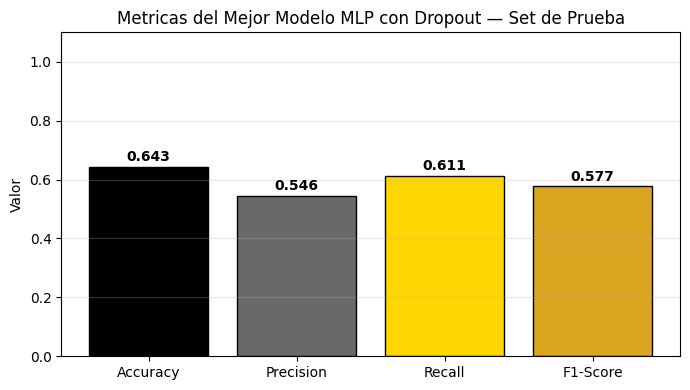

In [ ]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
valores  = [acc, prec, rec, f1]
colores  = ['black', 'dimgray', 'gold', 'goldenrod']

pyplot.figure(figsize=(7, 4))
bars = pyplot.bar(metricas, valores, color=colores, edgecolor='black')
pyplot.ylim(0, 1.1)
pyplot.ylabel('Valor')
pyplot.title('Metricas del Mejor Modelo MLP con Dropout — Set de Prueba')

# Etiqueta numerica encima de cada barra
for bar, val in zip(bars, valores):
    pyplot.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontweight='bold')

pyplot.grid(axis='y', alpha=0.3)
pyplot.tight_layout()
pyplot.show()

## 15 — Predicción para los Primeros 50 Pacientes del Set de Prueba

Se muestra el análisis individual del Lab 3, usando el modelo PyTorch con Dropout.
Para cada paciente:
- **Probabilidad predicha** (salida de Sigmoid): confianza del modelo en readmisión
- **Predicción** (umbral 0.5)
- **Valor real** y resultado (correcto / incorrecto)

Las probabilidades cercanas a 0.5 indican incertidumbre del modelo.

In [ ]:
print('=== PREDICCION PRIMEROS 50 PACIENTES DEL SET DE PRUEBA ===')

model.eval()  # Dropout desactivado
correctos   = 0
incorrectos = 0

X_muestra = torch.from_numpy(X_test_norm[:50]).float().to(device)
y_muestra = y_test[:50]

with torch.no_grad():
    logits = model(X_muestra).squeeze()
    probs  = torch.sigmoid(logits).cpu().numpy()

for i in range(50):
    prob_i = probs[i]
    pred_i = int(prob_i >= 0.5)
    real_i = int(y_muestra[i])
    if pred_i == real_i:
        correctos += 1
        estado = 'Correcto'
    else:
        incorrectos += 1
        estado = 'Incorrecto'
    print(f'Paciente {i+1:2d}: Prob={prob_i:.3f} | Pred={pred_i} | Real={real_i} | {estado}')

print()
print(f'=== RESUMEN DE LOS 50 PACIENTES ===')
print(f'Correctos:   {correctos}  ({correctos/50*100:.1f}%)')
print(f'Incorrectos: {incorrectos} ({incorrectos/50*100:.1f}%)')

=== PREDICCION PRIMEROS 50 PACIENTES DEL SET DE PRUEBA ===
Paciente  1: Prob=0.341 | Pred=0 | Real=1 | Incorrecto
Paciente  2: Prob=0.564 | Pred=1 | Real=1 | Correcto
Paciente  3: Prob=0.705 | Pred=1 | Real=1 | Correcto
Paciente  4: Prob=0.702 | Pred=1 | Real=1 | Correcto
Paciente  5: Prob=0.740 | Pred=1 | Real=1 | Correcto
Paciente  6: Prob=0.616 | Pred=1 | Real=0 | Incorrecto
Paciente  7: Prob=0.506 | Pred=1 | Real=0 | Incorrecto
Paciente  8: Prob=0.583 | Pred=1 | Real=1 | Correcto
Paciente  9: Prob=0.609 | Pred=1 | Real=1 | Correcto
Paciente 10: Prob=0.489 | Pred=0 | Real=1 | Incorrecto
Paciente 11: Prob=0.840 | Pred=1 | Real=0 | Incorrecto
Paciente 12: Prob=0.468 | Pred=0 | Real=0 | Correcto
Paciente 13: Prob=0.449 | Pred=0 | Real=0 | Correcto
Paciente 14: Prob=0.813 | Pred=1 | Real=1 | Correcto
Paciente 15: Prob=0.301 | Pred=0 | Real=1 | Incorrecto
Paciente 16: Prob=0.683 | Pred=1 | Real=1 | Correcto
Paciente 17: Prob=0.458 | Pred=0 | Real=1 | Incorrecto
Paciente 18: Prob=0.418 | 

## 16 — Guardado y Carga del Modelo (Cuadernillo 04)

Flujo completo del cuadernillo 04.
El `state_dict` guarda los pesos de todas las capas, incluyendo las del Dropout
(aunque Dropout no tiene pesos propios, su parámetro `p` vive en la arquitectura de la clase).

**`torch.save(model.state_dict(), PATH)`** — guarda solo los pesos  
**`model.load_state_dict(torch.load(PATH))`** — carga pesos en modelo instanciado  
**`model.eval()`** — siempre después de cargar para predicciones (desactiva Dropout)

In [ ]:
# GUARDAR el state_dict — cuadernillo 04
FINAL_PATH = '/content/drive/MyDrive/datasets/final_diabetes_mlp_dropout.pt'
torch.save(model.state_dict(), FINAL_PATH)
print(f'Modelo guardado en: {FINAL_PATH}')

# Ver que contiene el state_dict
state = model.state_dict()
print('\nCapas y formas de los parametros guardados:')
for nombre, tensor in state.items():
    print(f'  {nombre:20s}: {list(tensor.shape)}')

# CARGAR el modelo desde disco — cuadernillo 04
model_cargado = MLP(D_in).to(device)                         # instanciar vacio
model_cargado.load_state_dict(torch.load(FINAL_PATH))        # cargar pesos
model_cargado.eval()                                         # Dropout desactivado
print('\nModelo cargado correctamente desde disco')

# Verificar que produce las mismas predicciones
y_pred2, _ = evaluate(model_cargado, dataloader['test'])
acc2 = accuracy_score(y_true, y_pred2)
print(f'Accuracy del modelo cargado: {acc2*100:.2f}%  (debe coincidir con el anterior)')

Modelo guardado en: /content/drive/MyDrive/datasets/final_diabetes_mlp_dropout.pt

Capas y formas de los parametros guardados:
  fc1.weight          : [64, 42]
  fc1.bias            : [64]
  fc2.weight          : [32, 64]
  fc2.bias            : [32]
  fc3.weight          : [1, 32]
  fc3.bias            : [1]

Modelo cargado correctamente desde disco
Accuracy del modelo cargado: 64.27%  (debe coincidir con el anterior)


## 17 — Resumen y Conclusiones

### Lo que se aplicó de cada cuadernillo

| Cuadernillo | Concepto | Aplicación en este Lab |
|-------------|---------|----------------------|
| **02** | `torch.nn.Module`, `Linear`, `ReLU` | Clase `MLP` con 3 capas conectadas |
| **02** | `torch.nn.Dropout(p=0.3)` | Regularización anti-overfitting |
| **02** | `BCEWithLogitsLoss`, `Adam` + `weight_decay` | Pérdida binaria y optimizador |
| **02** | `zero_grad`, `backward`, `step` | Bucle de entrenamiento |
| **02** | `model.train()` / `model.eval()` | Activa/desactiva Dropout automáticamente |
| **03** | `torch.utils.data.Dataset` | Clase `DiabetesDataset` |
| **03** | `DataLoader` con `batch_size` y `shuffle` | Mini-batches sobre 80k+ registros |
| **04** | `torch.save(model.state_dict(), PATH)` | Checkpoint cuando mejora `val_acc` |
| **04** | `model.load_state_dict(torch.load(PATH))` | Restaurar mejor modelo |

### ¿Por qué el Dropout funciona?
Al apagar aleatoriamente el 30% de neuronas en cada paso de entrenamiento,
el modelo no puede depender de ninguna neurona específica para memorizar el train.
Esto fuerza a que la información se distribuya en toda la red y generalice mejor.
En evaluación (`model.eval()`) el Dropout se desactiva solo — todas las neuronas participan.

### Observación clínica
El **Recall** es la métrica más crítica: un Falso Negativo (readmisión no detectada)
puede significar que el paciente no reciba atención preventiva oportuna.
Un modelo con Dropout bien calibrado tiende a tener mejor Recall
porque generaliza mejor hacia los verdaderos patrones clínicos.